In [ ]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import os, time, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── CONFIG — change these ──────────────────────────────────────────────────────
NUM_EPOCHS    = 200      # 200 for full training, 20 for quick test
BATCH_SIZE    = 512       # 512 if you have >8GB VRAM
TEMPERATURE   = 0.5       # NT-Xent temperature τ
LR            = 1e-3      # base learning rate
WARMUP_EPOCHS = 10        # linear LR warmup
FEATURE_DIM   = 128       # projection head output dimension
SAVE_DIR      = '/content/simclr_checkpoints'
DATA_DIR      = '/content/data'

# Ablation flags — set True to run broken versions
NO_COLOR_JITTER    = False   # Ablation A
NO_PROJECTION_HEAD = False   # Ablation B

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'\nConfig:')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Temperature  : {TEMPERATURE}')
print(f'  Color jitter : {"DISABLED" if NO_COLOR_JITTER else "enabled"}')
print(f'  Proj head    : {"DISABLED" if NO_PROJECTION_HEAD else "enabled"}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Config:
  Epochs       : 200
  Batch size   : 512
  Temperature  : 0.5
  Color jitter : enabled
  Proj head    : enabled


In [ ]:
# ── Cell 2: SimCLR Augmentation ───────────────────────────────────────────────
# Source: adapted from leftthomas/SimCLR, Chen et al. 2020 Table 1
#
# For every image x, produces TWO independently augmented views xi and xj.
# These are the positive pair — the model must map them close together.

class SimCLRTransform:
    def __init__(self, image_size=32, disable_color_jitter=False):
        transforms = [
            # 1. Random crop — teaches part-whole relationships
            T.RandomResizedCrop(size=image_size, scale=(0.2, 1.0)),

            # 2. Horizontal flip — basic spatial invariance
            T.RandomHorizontalFlip(p=0.5),
        ]

        if not disable_color_jitter:
            # 3. Color jitter — THE MOST CRITICAL augmentation
            # Forces the model to learn shapes, not color histograms.
            # Without this: "green pixels = frog" (fails on colored MNIST)
            # With this: model learns actual tissue/object structure
            transforms.append(
                T.RandomApply(
                    [T.ColorJitter(brightness=0.8, contrast=0.8,
                                   saturation=0.8, hue=0.2)],
                    p=0.8
                )
            )

        transforms += [
            # 4. Random grayscale — further discourages color reliance
            T.RandomGrayscale(p=0.2),

            # 5. Gaussian blur — minimal effect at 32x32 but paper-faithful
            T.RandomApply(
                [T.GaussianBlur(kernel_size=int(0.1 * image_size) | 1)],
                p=0.5
            ),

            # 6. To tensor + CIFAR-10 normalization
            T.ToTensor(),
            T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2023, 0.1994, 0.2010]),
        ]

        self.transform = T.Compose(transforms)

    def __call__(self, x):
        # Apply TWICE independently → positive pair (xi, xj)
        return self.transform(x), self.transform(x)


# Verify
from PIL import Image
aug = SimCLRTransform(32)
dummy = Image.fromarray(np.uint8(np.random.rand(32,32,3)*255))
xi, xj = aug(dummy)
print(f'xi shape: {xi.shape}  xj shape: {xj.shape}')
print(f'xi == xj: {torch.allclose(xi, xj)}  (should be False — different augmentations)')
print('Augmentation OK ✓')

xi shape: torch.Size([3, 32, 32])  xj shape: torch.Size([3, 32, 32])
xi == xj: False  (should be False — different augmentations)
Augmentation OK ✓


In [ ]:
# ── Cell 3: SimCLR Model — ResNet-18 + Projection Head ────────────────────────
# Source: adapted from leftthomas/SimCLR model.py
#
# Architecture:
#   Input (3×32×32)
#     → ResNet-18 encoder (CIFAR-modified: kernel=3, no maxpool)
#     → h: 512-D  ← USE THIS for downstream tasks (Phase 2)
#     → MLP projection head
#     → z: 128-D  ← NT-Xent loss applied here
#
# Why two outputs?
#   The loss warps z to satisfy contrastive objectives.
#   The projection head absorbs this warping, keeping h clean.
#   (Chen et al. 2020, Figure 8 — removing the head drops accuracy ~10%)

class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128, use_projection_head=True):
        super().__init__()
        self.use_projection_head = use_projection_head

        # ResNet-18 backbone
        self.encoder = models.resnet18(weights=None)  # train from scratch

        # CIFAR-10 modification:
        # Default ResNet conv1 uses kernel=7, stride=2 → designed for 224×224.
        # On 32×32 this aggressively destroys spatial information.
        # Fix: kernel=3, stride=1, remove maxpool.
        self.encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                                        stride=1, padding=1, bias=False)
        self.encoder.maxpool = nn.Identity()

        # Remove the classification head — we want 512-D features
        self.encoder_dim = self.encoder.fc.in_features  # 512
        self.encoder.fc  = nn.Identity()

        # MLP projection head: 512 → 512 (BN+ReLU) → 128
        self.projection_head = nn.Sequential(
            nn.Linear(self.encoder_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, feature_dim)
        )

    def forward(self, x):
        h = self.encoder(x)                        # (B, 512) — keep for eval
        if self.use_projection_head:
            z = self.projection_head(h)             # (B, 128)
        else:
            z = h                                   # Ablation B: skip head
        z = F.normalize(z, dim=1)                  # L2 normalize for cosine sim
        return h, z


# Verify
test_model = SimCLRModel(128).eval()
dummy_batch = torch.randn(4, 3, 32, 32)
h, z = test_model(dummy_batch)
print(f'h shape: {h.shape}  (512-D encoder output)')
print(f'z shape: {z.shape}  (128-D projected, L2-normalized)')
print(f'z normalized: {torch.allclose(z.norm(dim=1), torch.ones(4), atol=1e-5)}')
total = sum(p.numel() for p in test_model.parameters())
print(f'Total params: {total:,}')
print('Model OK ✓')
del test_model

h shape: torch.Size([4, 512])  (512-D encoder output)
z shape: torch.Size([4, 128])  (128-D projected, L2-normalized)
z normalized: True
Total params: 11,498,176
Model OK ✓


In [ ]:
# ── Cell 4: NT-Xent Loss ──────────────────────────────────────────────────────
# Source: Chen et al. 2020 Equation 1, pattern from leftthomas/SimCLR utils.py
#
# Given batch of N images → 2N augmented views.
# For each view zi, its positive is zj (other augmentation of same image).
# All other 2(N-1) views are negatives.
#
# Loss = -log( exp(sim(zi,zj)/τ) / Σ_{k≠i} exp(sim(zi,zk)/τ) )
#
# This is cross-entropy: "which of the 2N-1 views is my pair?"

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.criterion   = nn.CrossEntropyLoss(reduction='mean')

    def forward(self, zi, zj):
        """
        zi: (N, D) — first views, L2-normalized
        zj: (N, D) — second views, L2-normalized
        """
        N      = zi.shape[0]
        device = zi.device

        # Concatenate → (2N, D)
        z = torch.cat([zi, zj], dim=0)

        # Full 2N×2N cosine similarity matrix (dot product since L2-normalized)
        sim = torch.matmul(z, z.T) / self.temperature  # (2N, 2N)

        # Mask out self-similarity (diagonal)
        mask = torch.eye(2*N, dtype=torch.bool, device=device)
        sim  = sim.masked_fill(mask, float('-inf'))

        # Labels: zi[i] pairs with zj[i] = index i+N, and vice versa
        labels = torch.cat([
            torch.arange(N, 2*N, device=device),
            torch.arange(0, N,   device=device)
        ])

        return self.criterion(sim, labels)


# Sanity check: perfect pairs should give lower loss than random
loss_fn = NTXentLoss(0.5)
zi_rand = F.normalize(torch.randn(32, 128), dim=1)
zj_rand = F.normalize(torch.randn(32, 128), dim=1)
zi_perf = F.normalize(torch.randn(32, 128), dim=1)
zj_perf = zi_perf.clone()
loss_rand = loss_fn(zi_rand, zj_rand)
loss_perf = loss_fn(zi_perf, zj_perf)
print(f'Random pairs loss : {loss_rand.item():.4f}')
print(f'Perfect pairs loss: {loss_perf.item():.4f}')
print(f'Loss correctly lower for perfect pairs: {loss_perf < loss_rand}')
print(f'Random init loss ≈ log(2N-1) = {np.log(2*32-1):.4f}  (expected baseline)')
print('Loss OK ✓')

Random pairs loss : 4.2183
Perfect pairs loss: 2.2586
Loss correctly lower for perfect pairs: True
Random init loss ≈ log(2N-1) = 4.1431  (expected baseline)
Loss OK ✓


In [ ]:
# ── Cell 5: Dataset + DataLoader ──────────────────────────────────────────────

class CIFAR10Pair(CIFAR10):
    """
    Wraps CIFAR-10 to return (xi, xj, label) instead of (x, label).
    label is stored for monitoring only — NOT used in the contrastive loss.
    """
    def __init__(self, *args, pair_transform=None, **kwargs):
        super().__init__(*args, transform=None, **kwargs)
        self.pair_transform = pair_transform

    def __getitem__(self, idx):
        img, label = super().__getitem__(idx)
        xi, xj = self.pair_transform(img)
        return xi, xj, label


augment = SimCLRTransform(
    image_size=32,
    disable_color_jitter=NO_COLOR_JITTER
)

train_dataset = CIFAR10Pair(
    root=DATA_DIR, train=True, download=True,
    pair_transform=augment
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,#if num =0 then prefetch_factor option could only be specified in multiprocessing.let num_workers > 0 to enable multiprocessing, otherwise set prefetch_factor to None.
    #The worker crashed because persistent_workers=True with num_workers=2 is unstable on Colab with Python 3.12 make it num_worker =0 again
    pin_memory=True,
    drop_last=True,   # NT-Xent requires consistent batch size
    #persistent_workers=True,  # ← ADD THIS — keeps workers alive between epochs
   # prefetch_factor=2,
)

print(f'CIFAR-10 train: {len(train_dataset):,} images')
print(f'Batches/epoch : {len(train_loader)}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Steps/epoch   : {len(train_loader)}')

# Check one batch
xi_b, xj_b, lbls = next(iter(train_loader))
print(f'\nBatch xi: {xi_b.shape}  xj: {xj_b.shape}  labels: {lbls.shape}')
print(f'xi == xj: {torch.allclose(xi_b, xj_b)}  (should be False)')
print('Dataset OK ✓')

CIFAR-10 train: 50,000 images
Batches/epoch : 97
Batch size    : 512
Steps/epoch   : 97

Batch xi: torch.Size([512, 3, 32, 32])  xj: torch.Size([512, 3, 32, 32])  labels: torch.Size([512])
xi == xj: False  (should be False)
Dataset OK ✓


In [ ]:
# ── Cell 6: Model + Optimizer + Scheduler ────────────────────────────────────

model = SimCLRModel(
    feature_dim=FEATURE_DIM,
    use_projection_head=(not NO_PROJECTION_HEAD)
).to(device)

criterion = NTXentLoss(temperature=TEMPERATURE)

# Adam with small weight decay (from leftthomas/SimCLR)
# Note: paper uses LARS for batch_size >= 2048.
# For batch_size=256, Adam converges well enough.
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-6)

# LR schedule: linear warmup → cosine annealing
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Mixed precision scaler for faster training on T4
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {trainable:,}')
print(f'Optimizer       : Adam (lr={LR}, wd=1e-6)')
print(f'Scheduler       : {WARMUP_EPOCHS} epoch warmup + cosine annealing')
print(f'Mixed precision : {device.type == "cuda"}')
print('Setup OK ✓')

Model parameters: 11,498,176
Optimizer       : Adam (lr=0.001, wd=1e-6)
Scheduler       : 10 epoch warmup + cosine annealing
Mixed precision : True
Setup OK ✓


/tmp/ipykernel_1406/1725244384.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [ ]:
#cell 6b
# ── RESUME CELL — run this after cells 1-6 if Colab disconnected ──────────────

import os, glob

# Find the latest checkpoint automatically
checkpoints = sorted(glob.glob(f'{SAVE_DIR}/checkpoint_epoch_*.pth'))

if checkpoints:
    latest = checkpoints[-1]
    ckpt = torch.load(latest, weights_only=True)
    model.load_state_dict(ckpt['state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    loss_history = ckpt['loss_history']
    best_loss    = ckpt['best_loss']
    START_EPOCH  = ckpt['epoch'] + 1
    print(f'✓ Resumed from {latest}')
    print(f'  Epoch     : {ckpt["epoch"]}')
    print(f'  Loss      : {loss_history[-1]:.4f}')
    print(f'  Best loss : {best_loss:.4f}')
    print(f'  Continuing from epoch {START_EPOCH}')
else:
    START_EPOCH = 1
    best_loss   = float('inf')
    loss_history = []
    print('No checkpoint found — starting fresh from epoch 1')

No checkpoint found — starting fresh from epoch 1


In [26]:
# ── Cell 7: Training Loop ─────────────────────────────────────────────────────
# Expected loss trajectory:
#   Epoch 1  : ~6.5  (≈ log(2*batch_size) at random init)
#   Epoch 10 : ~5.0  (after warmup)
#   Epoch 50 : ~3.5
#   Epoch 200: ~2.2

# ── Cell 7: Training Loop (with guaranteed checkpointing) ─────────────────────

START_EPOCH = START_EPOCH if 'START_EPOCH' in vars() else 1

best_loss    = best_loss    if 'best_loss'    in vars() else float('inf')
loss_history = loss_history if 'loss_history' in vars() else []

print(f'Starting from epoch {START_EPOCH}')
print(f'Starting training: {NUM_EPOCHS} epochs, batch={BATCH_SIZE}, τ={TEMPERATURE}')
print(f'Color jitter : {"DISABLED" if NO_COLOR_JITTER else "enabled"}')
print(f'Proj head    : {"DISABLED" if NO_PROJECTION_HEAD else "enabled"}')
print('='*60)

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    model.train()
    epoch_loss  = 0.0
    epoch_start = time.time()

    for xi, xj, _ in tqdm(train_loader, desc=f'Epoch {epoch:03d}', leave=False):
        xi = xi.to(device, non_blocking=True)
        xj = xj.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            _, zi = model(xi)
            _, zj = model(xj)
            loss  = criterion(zi, zj)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    elapsed  = time.time() - epoch_start
    lr_now   = optimizer.param_groups[0]['lr']
    loss_history.append(avg_loss)

    print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | Loss {avg_loss:.4f} | LR {lr_now:.6f} | Time {elapsed:.0f}s')

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch'       : epoch,
            'state_dict'  : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'scheduler'   : scheduler.state_dict(),
            'loss_history': loss_history,
            'best_loss'   : best_loss,
            'config'      : {
                'temperature'        : TEMPERATURE,
                'batch_size'         : BATCH_SIZE,
                'no_color_jitter'    : NO_COLOR_JITTER,
                'no_projection_head' : NO_PROJECTION_HEAD,
            }
        }, f'{SAVE_DIR}/best_model.pth')
        print(f'  ✓ New best loss: {best_loss:.4f}')

    # Save every 5 epochs — guaranteed, always runs
    if epoch % 5 == 0:
        ckpt_path = f'{SAVE_DIR}/checkpoint_epoch_{epoch}.pth'
        torch.save({
            'epoch'       : epoch,
            'state_dict'  : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'scheduler'   : scheduler.state_dict(),
            'loss_history': loss_history,
            'best_loss'   : best_loss,
        }, ckpt_path)
        print(f'  💾 Checkpoint saved → {ckpt_path}')

with open(f'{SAVE_DIR}/loss_history.json', 'w') as f:
    json.dump({'loss_history': loss_history}, f)
print(f'\nTraining complete! Best loss: {best_loss:.4f}')

Starting from epoch 1
Starting training: 200 epochs, batch=512, τ=0.5
Color jitter : enabled
Proj head    : enabled


Epoch 001:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 001/200 | Loss 6.4448 | LR 0.000200 | Time 165s
  ✓ New best loss: 6.4448


Epoch 002:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 002/200 | Loss 6.1520 | LR 0.000300 | Time 164s
  ✓ New best loss: 6.1520


...

Epoch 198/200 | Loss 5.2277 | LR 0.000000 | Time 162s


Epoch 199:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 199/200 | Loss 5.2275 | LR 0.000000 | Time 161s


Epoch 200:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 200/200 | Loss 5.2250 | LR 0.000000 | Time 163s
  ✓ New best loss: 5.2250
  💾 Checkpoint saved → /content/simclr_checkpoints/checkpoint_epoch_200.pth

Training complete! Best loss: 5.2250


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [29]:
# ── Cell 8: Save encoder-only weights for Phase 2 ────────────────────────────
# Phase 2 only needs the ResNet-18 encoder (h), not the projection head.
# We save encoder weights separately so Phase 2 can load them cleanly.

# Load best model
checkpoint = torch.load(f'{SAVE_DIR}/best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} '
      f'(loss={checkpoint["best_loss"]:.4f})')

# Extract encoder-only weights
encoder_state = {
    k: v for k, v in model.state_dict().items()
    if k.startswith('encoder.')
}
torch.save(encoder_state, f'{SAVE_DIR}/encoder_weights.pth')
print(f'Saved encoder weights ({len(encoder_state)} tensors) '
      f'→ {SAVE_DIR}/encoder_weights.pth')
print('These will be loaded (frozen) in Phase 2 for MNIST evaluation.')

# List saved files
print('\nFiles in checkpoint directory:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1e6
    print(f'  {f}  ({size:.1f} MB)')

Loaded best model from epoch 200 (loss=5.2250)
Saved encoder weights (120 tensors) → /content/simclr_checkpoints/encoder_weights.pth
These will be loaded (frozen) in Phase 2 for MNIST evaluation.

Files in checkpoint directory:
  best_model.pth  (138.1 MB)
  checkpoint_epoch_10.pth  (138.1 MB)
  checkpoint_epoch_100.pth  (138.1 MB)
  checkpoint_epoch_105.pth  (138.1 MB)
  checkpoint_epoch_110.pth  (138.1 MB)
  checkpoint_epoch_115.pth  (138.1 MB)
  checkpoint_epoch_120.pth  (138.1 MB)
  checkpoint_epoch_125.pth  (138.1 MB)
  checkpoint_epoch_130.pth  (138.1 MB)
  checkpoint_epoch_135.pth  (138.1 MB)
  checkpoint_epoch_140.pth  (138.1 MB)
  checkpoint_epoch_145.pth  (138.1 MB)
  checkpoint_epoch_15.pth  (138.1 MB)
  checkpoint_epoch_150.pth  (138.1 MB)
  checkpoint_epoch_155.pth  (138.1 MB)
  checkpoint_epoch_160.pth  (138.1 MB)
  checkpoint_epoch_165.pth  (138.1 MB)
  checkpoint_epoch_170.pth  (138.1 MB)
  checkpoint_epoch_175.pth  (138.1 MB)
  checkpoint_epoch_180.pth  (138.1 MB)
  ch

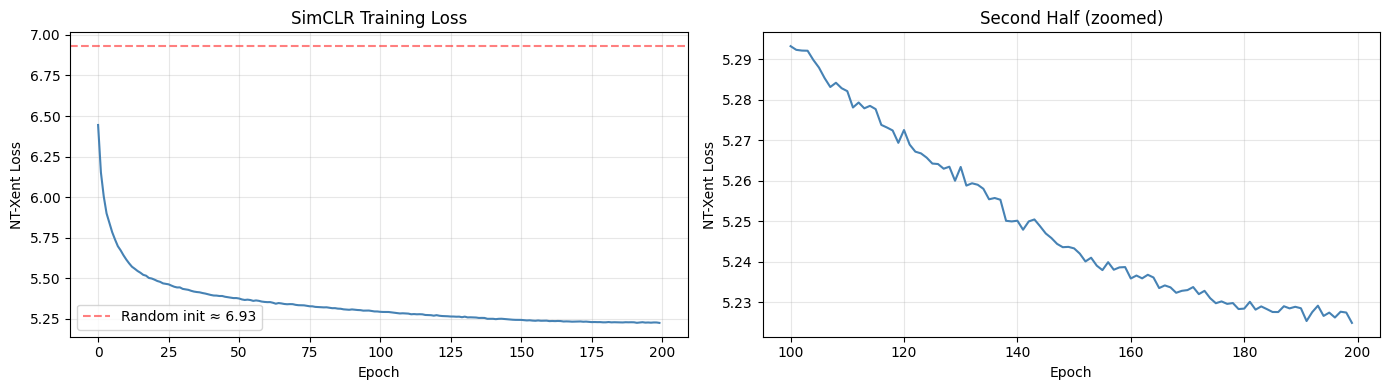

Final loss: 5.2250  |  Best loss: 5.2250


In [30]:
# ── Cell 9: Training Curve Plot ───────────────────────────────────────────────

with open(f'{SAVE_DIR}/loss_history.json') as f:
    history = json.load(f)['loss_history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Full curve
ax1.plot(history, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('NT-Xent Loss')
ax1.set_title('SimCLR Training Loss')
ax1.grid(alpha=0.3)
ax1.axhline(y=np.log(2*BATCH_SIZE - 1), color='red',
             linestyle='--', alpha=0.5, label=f'Random init ≈ {np.log(2*BATCH_SIZE-1):.2f}')
ax1.legend()

# Smoothed last half
half = len(history) // 2
ax2.plot(range(half, len(history)), history[half:],
         color='steelblue', linewidth=1.5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('NT-Xent Loss')
ax2.set_title('Second Half (zoomed)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final loss: {history[-1]:.4f}  |  Best loss: {min(history):.4f}')

Extracting features for t-SNE...


  0%|          | 0/40 [00:00<?, ?it/s]

Running t-SNE (takes ~1 min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


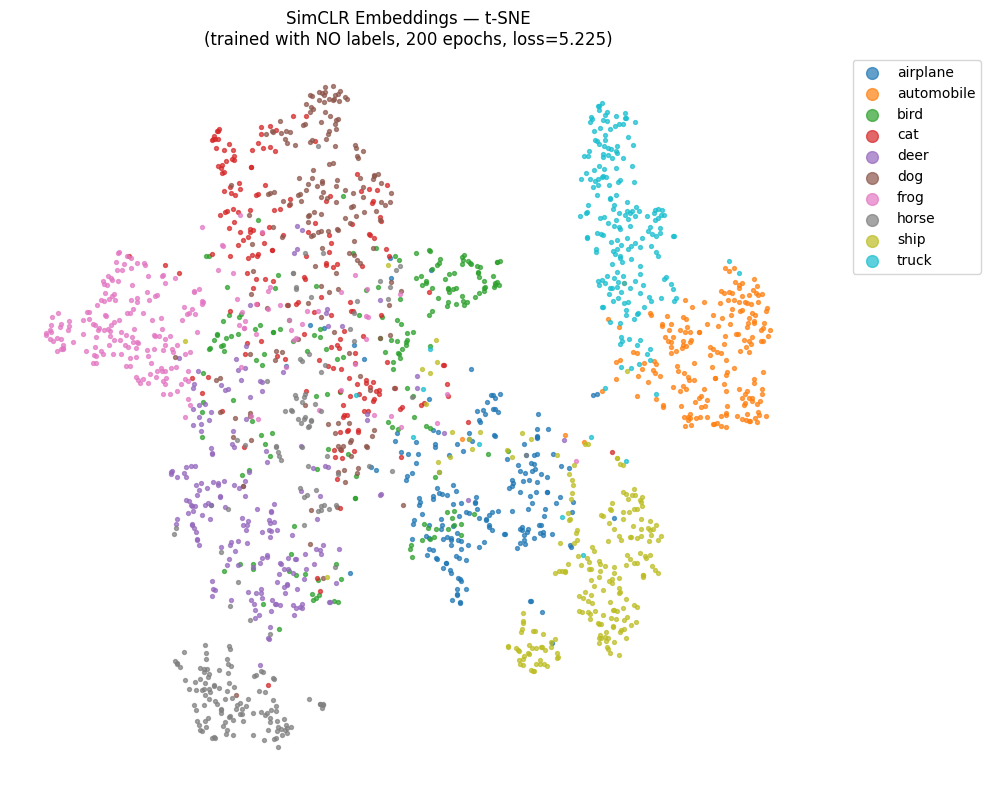

If clusters are visible → model learned semantic structure without labels ✓


In [34]:
# ── Cell 10: t-SNE Visualization of Learned Embeddings ───────────────────────
# Extracts 512-D features (h) for 2000 CIFAR-10 test images
# and projects to 2D with t-SNE.
# Good representation: same-class points cluster together
# even though the model NEVER saw class labels during training.

from sklearn.manifold import TSNE
from torchvision.datasets import CIFAR10

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                    'dog','frog','horse','ship','truck']
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

# Standard eval transform (no augmentation)
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std=[0.2023, 0.1994, 0.2010])
])

test_dataset = CIFAR10(root=DATA_DIR, train=False,
                        download=True, transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=256,
                           shuffle=False, num_workers=2)

# Extract features from first 2000 images
print('Extracting features for t-SNE...')
model.eval()
all_h, all_y = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, leave=False):
        h, _ = model(imgs.to(device))
        all_h.append(h.cpu())
        all_y.append(labels)
        if sum(len(x) for x in all_h) >= 2000:
            break

features = torch.cat(all_h)[:2000].numpy()
labels   = torch.cat(all_y)[:2000].numpy()

# t-SNE
print('Running t-SNE (takes ~1 min)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
emb  = tsne.fit_transform(features)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    ax.scatter(emb[mask, 0], emb[mask, 1],
               c=[COLORS[cls]], label=CIFAR10_CLASSES[cls],
               s=8, alpha=0.7)

ax.legend(markerscale=3, bbox_to_anchor=(1.05, 1))
ax.set_title(f'SimCLR Embeddings — t-SNE\n'
             f'(trained with NO labels, {len(history)} epochs, '
             f'loss={history[-1]:.3f})')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('If clusters are visible → model learned semantic structure without labels ✓')

In [32]:
# ── Cell 11: Quick Linear Probe Evaluation on CIFAR-10 ───────────────────────
# Attaches one Linear(512→10) on frozen encoder.
# Trains only that layer for 20 epochs.
# This measures if features are linearly separable.
# Good SimCLR after 200 epochs: ~80–88% on CIFAR-10.

print('Linear probe evaluation on CIFAR-10 test set...')

# Freeze encoder
for p in model.encoder.parameters():
    p.requires_grad = False

# Linear classifier on top
linear_head = nn.Linear(512, 10).to(device)
probe_opt   = optim.Adam(linear_head.parameters(), lr=1e-3)
probe_crit  = nn.CrossEntropyLoss()

# Train loader with standard transform
train_probe = CIFAR10(root=DATA_DIR, train=True,
                       download=False, transform=eval_transform)
probe_loader = DataLoader(train_probe, batch_size=512,
                           shuffle=True, num_workers=2)

PROBE_EPOCHS = 20
for epoch in range(1, PROBE_EPOCHS + 1):
    linear_head.train(); model.eval()
    for imgs, lbls in tqdm(probe_loader, desc=f'Probe {epoch:02d}', leave=False):
        with torch.no_grad():
            h, _ = model(imgs.to(device))
        logits = linear_head(h)
        loss   = probe_crit(logits, lbls.to(device))
        probe_opt.zero_grad()
        loss.backward()
        probe_opt.step()

# Evaluate
linear_head.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        h, _ = model(imgs.to(device))
        preds = linear_head(h).argmax(dim=1)
        correct += (preds == lbls.to(device)).sum().item()
        total   += len(lbls)

probe_acc = correct / total
print(f'\nLinear probe accuracy: {probe_acc:.4f} ({probe_acc*100:.2f}%)')
print(f'Random baseline      : 10.00%')
print(f'Fully supervised ResNet-18: ~93%')
print(f'Good SimCLR (200 ep) : ~80–88%')

# Unfreeze encoder again (in case you continue training)
for p in model.encoder.parameters():
    p.requires_grad = True

Linear probe evaluation on CIFAR-10 test set...


Probe 01:   0%|          | 0/98 [00:00<?, ?it/s]

Probe 02:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in:     if w.is_alive():
  if w.is_alive(): <function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>
   
    ^Traceback (most recent call last):
 ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py",

Probe 03:   0%|          | 0/98 [00:00<?, ?it/s]

...

Probe 19:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
       self._shutdown_workers() 
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive(): 
     ^ ^  ^  ^^^^^^^^^^^^^^^^^^^^^^

Probe 20:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7975b51487c0>^^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^   ^  ^


Linear probe accuracy: 0.8596 (85.96%)
Random baseline      : 10.00%
Fully supervised ResNet-18: ~93%
Good SimCLR (200 ep) : ~80–88%


In [33]:
# ── Cell 12: Download checkpoints from Colab ──────────────────────────────────
# Downloads the encoder weights needed for Phase 2.

from google.colab import files

# Download the encoder weights (needed for Phase 2)
files.download(f'{SAVE_DIR}/encoder_weights.pth')

# Download the full best model (for resuming or ablations)
files.download(f'{SAVE_DIR}/best_model.pth')

# Download plots
files.download(f'{SAVE_DIR}/training_curve.png')
files.download(f'{SAVE_DIR}/tsne.png')

print('Downloaded:')
print('  encoder_weights.pth  ← needed for Phase 2')
print('  best_model.pth       ← full model with projection head')
print('  training_curve.png   ← loss over epochs')
print('  tsne.png             ← embedding visualization')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded:
  encoder_weights.pth  ← needed for Phase 2
  best_model.pth       ← full model with projection head
  training_curve.png   ← loss over epochs
  tsne.png             ← embedding visualization
